## Fatbox for numerical modelling – spherical extraction

This notebook follows the same progression as the planar numerical-model extraction tutorial, but for a global spherical dataset. We first inspect **one output step by step**, then wrap the same operations into a short batch workflow.

The spherical workflow keeps geographic node positions as `(longitude, latitude)` in degrees. It handles the dateline periodically and does not exclude the Southern Hemisphere. The tutorial uses small prepared rasters included with Fatbox, so learners do not need the original model or its native files.

### Workflow

1. Read a small prepared spherical surface archive.
2. Inspect the strain-rate raster and choose a threshold.
3. Threshold and skeletonise the strain-rate field.
4. Convert the skeleton to a periodic NetworkX graph `G`.
5. Check coordinates, dateline edges and both hemispheres.
6. Repeat and save graphs for any chronological sequence of outputs.

### Imports

Run the notebook from the Fatbox repository or change `fatbox_directory` below. The prepared tutorial archives require only NumPy, NetworkX, SciPy, scikit-image and Matplotlib.

In [1]:
from pathlib import Path
import json
import pickle
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

fatbox_directory = Path.cwd().resolve()
if not (fatbox_directory / 'modules').is_dir():
    fatbox_directory = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(fatbox_directory / 'modules'))

import spherical_surface
import spherical

### Parameters

All user choices are kept in one cell, as in the other Fatbox numerical-model tutorials. `data_directory` points to the small teaching dataset distributed with Fatbox. The manifest lists the available outputs and their model times. `output_numbers` is the chronological sequence we want to follow; it can contain every available output or a selected subset.

`strain_threshold` controls which strain-rate pixels are interpreted as active boundaries. Check it visually for your model: early outputs may precede strain localisation and therefore should not be interpreted as mature plate boundaries.

In [2]:
data_directory = fatbox_directory / 'tutorials' / 'numerical_modelling' / 'data' / 'spherical_example'
manifest = json.loads((data_directory / 'manifest.json').read_text())
available_outputs = tuple(entry['number'] for entry in manifest['outputs'])
output_numbers = available_outputs  # or choose an ordered subset
example_output = output_numbers[-1]
grid_shape = (180, 360)          # latitude pixels, longitude pixels
strain_threshold = 5e-16         # s^-1
minimum_component_size = 4       # skeleton pixels
results_directory = fatbox_directory / 'tutorial_output' / 'spherical'
results_directory.mkdir(parents=True, exist_ok=True)

output_times = {entry['number']: entry['time_years'] for entry in manifest['outputs']}
[(number, output_times[number] / 1e6) for number in output_numbers]

[(220, 547.5062595137),
 (221, 550.0040610054),
 (222, 552.5013899754),
 (223, 555.0047336783),
 (224, 557.5018800216),
 (225, 560.0098205021),
 (226, 562.5067711526001),
 (227, 565.0064530013),
 (228, 567.5012892866),
 (229, 570.0036910072),
 (230, 572.5039121824)]

### 1. Read one prepared spherical surface archive

Each archive contains only two ready-to-use rasters: strain-rate magnitude for extraction and correlation, and three-component surface velocity for the optional slip-rate calculation in Tutorial 4. Meshes, cells, full tensors and unrelated model fields are not included.

In [3]:
surface_file = data_directory / f'spherical_surface_{example_output:05d}.npz'
surface = spherical_surface.read_surface_archive(surface_file)
assert surface['output_number'] == example_output
print(f"Output: {surface['output_number']:05d}")
print(f"Model time: {surface['time_years'] / 1e6:.1f} My")
print(f"Raster shape: {surface['grid_shape']}")
print(f"Compressed archive: {surface_file.stat().st_size / 1024:.0f} KiB")

Output: 00230
Model time: 572.5 My
Raster shape: (180, 360)
Compressed archive: 865 KiB


### 2. Inspect strain rate and the selected threshold

The cyan contour is the boundary of the thresholded mask. It should follow localised high-strain structures rather than cover most of the globe.

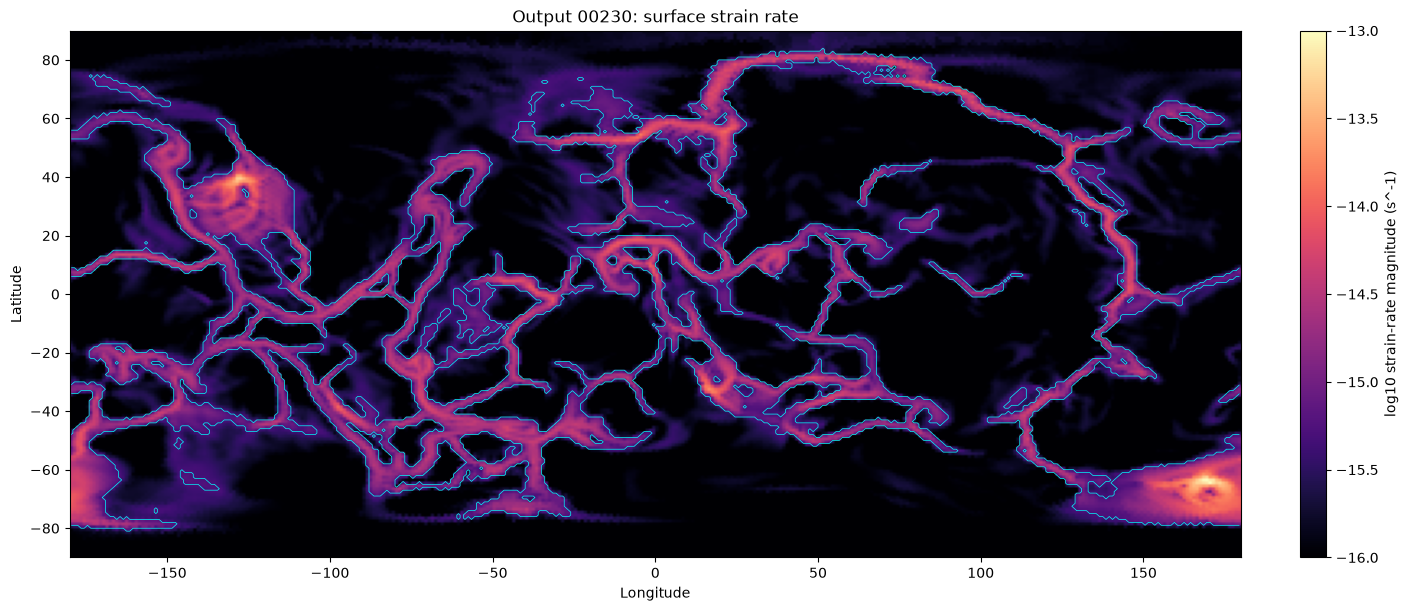

In [4]:
log_strain = np.log10(np.clip(surface['strain'], 1e-30, None))
mask = surface['strain'] > strain_threshold
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)
image = ax.imshow(log_strain, extent=(-180, 180, -90, 90), origin='upper', cmap='magma', vmin=-16, vmax=-13, aspect='auto')
ax.contour(mask.astype(float), levels=[0.5], extent=(-180, 180, -90, 90), origin='upper', colors='cyan', linewidths=0.5)
ax.set(title=f'Output {example_output:05d}: surface strain rate', xlabel='Longitude', ylabel='Latitude')
fig.colorbar(image, ax=ax, label='log10 strain-rate magnitude (s^-1)');

### 3. Extract the spherical graph

Every retained skeleton pixel becomes a graph node. Node `pos` stores geographic coordinates, edge `length` is a great-circle distance in kilometres, and edge `strike` is a geodesic strike in degrees. Connected components receive independent `fault` labels for this output.

In [5]:
G, mask, skeleton = spherical_surface.extract_fault_graph(
    surface['strain'], strain_threshold, minimum_component_size
)
fault_labels = sorted(set(nx.get_node_attributes(G, 'fault').values()))
print(f'Nodes: {G.number_of_nodes():,}')
print(f'Edges: {G.number_of_edges():,}')
print(f'Independent networks: {len(fault_labels)}')

Nodes: 3,103
Edges: 3,509
Independent networks: 9


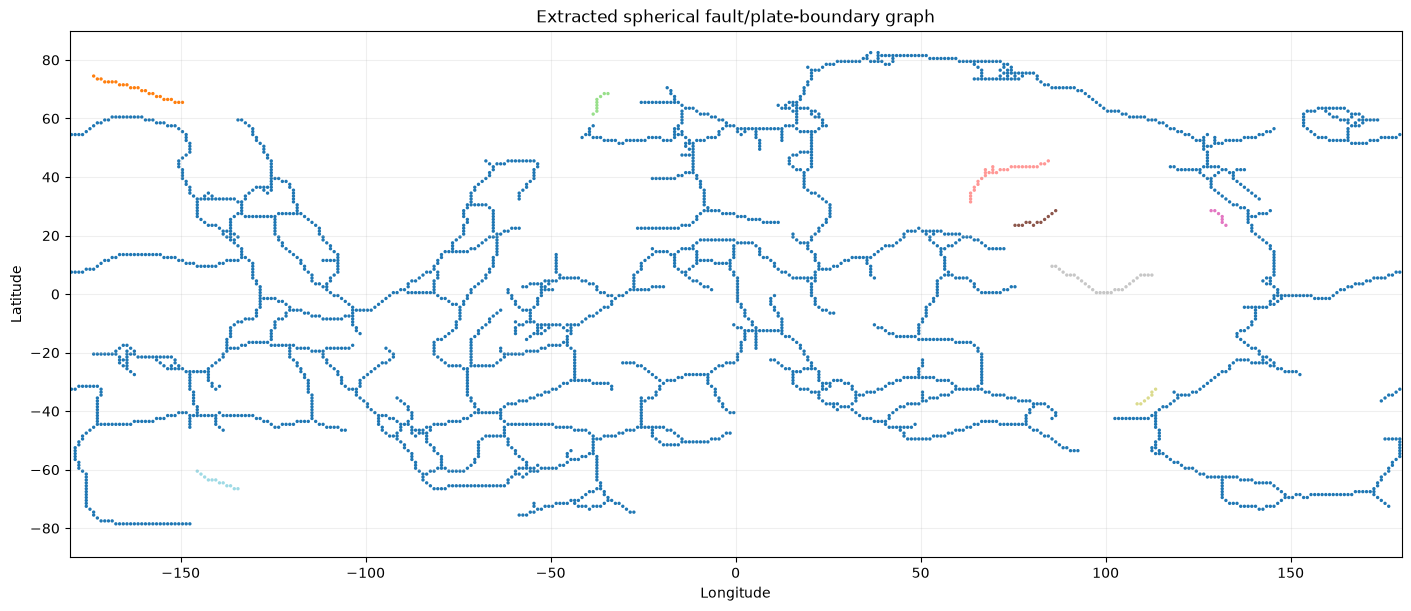

In [6]:
positions = nx.get_node_attributes(G, 'pos')
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)
ax.scatter(
    [positions[node][0] for node in G],
    [positions[node][1] for node in G],
    c=[G.nodes[node]['fault'] for node in G], s=2, cmap='tab20'
)
ax.set(title='Extracted spherical fault/plate-boundary graph', xlabel='Longitude', ylabel='Latitude', xlim=(-180, 180), ylim=(-90, 90))
ax.grid(alpha=0.2);

### 4. Quality checks

A dateline edge is expected when a boundary crosses from +180° to -180°. Its geodesic length must nevertheless remain short. We also explicitly check that Southern Hemisphere nodes have not been filtered.

In [7]:
edge_lengths = np.array(list(nx.get_edge_attributes(G, 'length').values()))
dateline_edges = [(u, v) for u, v in G.edges if abs(positions[u][0] - positions[v][0]) > 180]
southern_nodes = [node for node in G if positions[node][1] < 0]
assert edge_lengths.max() < 200, 'A long edge suggests a longitude-seam error'
assert southern_nodes, 'No Southern Hemisphere nodes were retained'
print(f'Dateline-crossing edges: {len(dateline_edges)}')
print(f'Maximum edge length: {edge_lengths.max():.2f} km')
print(f'Southern Hemisphere nodes: {len(southern_nodes):,}')

Dateline-crossing edges: 3
Maximum edge length: 157.25 km
Southern Hemisphere nodes: 1,624


### 5. Apply the extraction to several outputs

The following function contains exactly the operations demonstrated above. Each graph is saved as `G_XXXXX.pickle` for the correlation and slip tutorial. At this stage the labels are still local: fault 0 in one output is not necessarily fault 0 in the next output. Tutorial 4 will create persistent labels.

In [8]:
def extract_output(output_number):
    path = data_directory / f'spherical_surface_{output_number:05d}.npz'
    current_surface = spherical_surface.read_surface_archive(path)
    current_G, current_mask, current_skeleton = spherical_surface.extract_fault_graph(
        current_surface['strain'], strain_threshold, minimum_component_size
    )
    record = {
        'output_number': output_number,
        'time_years': current_surface['time_years'],
        'grid_shape': current_surface['grid_shape'],
        'strain_threshold': strain_threshold,
        'minimum_component_size': minimum_component_size,
        'graph': current_G,
    }
    destination = results_directory / f'G_{output_number:05d}.pickle'
    with destination.open('wb') as stream:
        pickle.dump(record, stream)
    return record

records = {}
for number in output_numbers:
    records[number] = extract_output(number)
    graph = records[number]['graph']
    faults = len(set(nx.get_node_attributes(graph, 'fault').values()))
    print(f'Output {number:05d}: {graph.number_of_nodes():,} nodes, {faults} local networks')

Output 00220: 2,983 nodes, 15 local networks


Output 00221: 3,017 nodes, 13 local networks


Output 00222: 3,106 nodes, 12 local networks


Output 00223: 3,124 nodes, 16 local networks


Output 00224: 3,094 nodes, 12 local networks


...

Output 00226: 3,057 nodes, 10 local networks


Output 00227: 3,076 nodes, 7 local networks


Output 00228: 3,048 nodes, 7 local networks


Output 00229: 3,049 nodes, 9 local networks


Output 00230: 3,103 nodes, 9 local networks


### 6. Check the extracted sequence

Before correlating anything, plot how many graph nodes and independent local networks were extracted. A sudden jump often indicates that the threshold is selecting a different kind of structure, so it is worth stopping here and checking the strain maps.

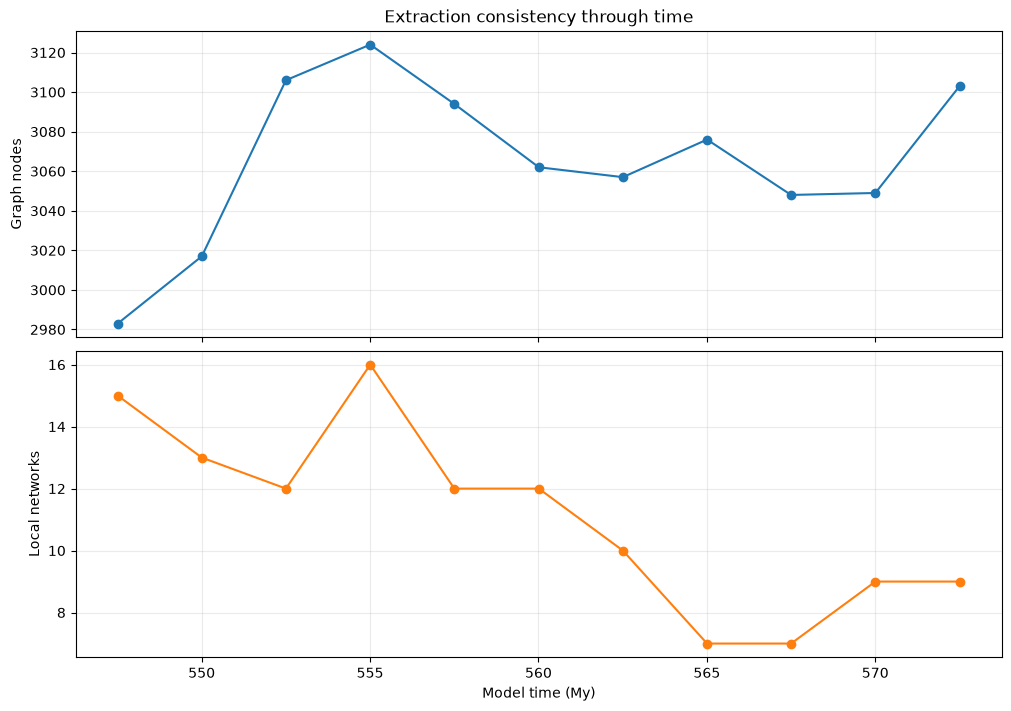

In [9]:
times_myr = np.array([records[number]['time_years'] / 1e6 for number in output_numbers])
node_counts = np.array([records[number]['graph'].number_of_nodes() for number in output_numbers])
fault_counts = np.array([len(set(nx.get_node_attributes(records[number]['graph'], 'fault').values())) for number in output_numbers])
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
axes[0].plot(times_myr, node_counts, 'o-')
axes[0].set(ylabel='Graph nodes', title='Extraction consistency through time')
axes[1].plot(times_myr, fault_counts, 'o-', color='tab:orange')
axes[1].set(xlabel='Model time (My)', ylabel='Local networks')
for ax in axes:
    ax.grid(alpha=0.25);

### Summary

We now have one independent spherical graph for every selected output. The graph geometry has been checked at the dateline and in the Southern Hemisphere, and the sequence-level extraction counts have been inspected. Continue with **`tuto_num4_spherical_correlation_slip.ipynb`** to learn correlation on one pair before applying it progressively to the complete sequence.